In [1]:
import os
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
file_path = r"C:\Users\LENOVO\Desktop\Expense_Model\expense_dataset.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (110000, 21)


,User_ID,Year,Month,Monthly_Income,Bills,Education,Entertainment,Food,Health,Shopping,...,Travel,Total_Expense,Savings,Savings_Rate,Expense_Ratio,Average_Daily_Expense,Weekend_Spending_Percentage,Transaction_Count,Spending_Profile,NextMonthExpense
0,U00001,2025,1,146919.89,18181.21,24989.66,4224.07,1286.79,2855.04,6148.05,...,18804.57,83974.51,62945.38,0.4284,0.5716,2799.15,21.64,64,Conservative,82862.49
1,U00001,2025,2,136686.15,2962.98,1506.22,4859.21,33775.74,4605.29,8628.82,...,14322.37,82862.49,53823.66,0.3938,0.6062,2762.08,19.40,30,Conservative,82554.05
2,U00001,2025,3,139109.12,39399.34,3482.08,8255.10,4296.83,4024.55,451.19,...,11290.27,82554.05,56555.07,0.4066,0.5934,2751.80,34.07,105,Conservative,84221.71
3,U00001,2025,4,137749.26,2944.78,21537.40,2469.06,1411.24,6061.04,38263.22,...,2498.67,84221.71,53527.55,0.3886,0.6114,2807.39,34.08,72,Conservative,87388.16
4,U00001,2025,5,143849.44,4196.16,20147.00,7091.05,15472.78,15524.34,11867.61,...,1463.44,87388.16,56461.28,0.3925,0.6075,2912.94,21.17,54,Conservative,92336.05


In [8]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Columns:
['User_ID', 'Year', 'Month', 'Monthly_Income', 'Bills', 'Education', 'Entertainment', 'Food', 'Health', 'Shopping', 'Transport', 'Travel', 'Total_Expense', 'Savings', 'Savings_Rate', 'Expense_Ratio', 'Average_Daily_Expense', 'Weekend_Spending_Percentage', 'Transaction_Count', 'Spending_Profile', 'NextMonthExpense']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110000 entries, 0 to 109999
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   User_ID                      110000 non-null  object 
 1   Year                         110000 non-null  int64  
 2   Month                        110000 non-null  int64  
 3   Monthly_Income               110000 non-null  float64
 4   Bills                        110000 non-null  float64
 5   Education                    110000 non-null  float64
 6   Entertainment                110000 non-null  float64
 7   Food 

In [9]:
print(df["NextMonthExpense"].describe())

count    110000.000000
mean     102558.814894
std       52809.487222
min       13058.140000
25%       59812.930000
50%       96769.855000
75%      137032.035000
max      331252.080000
Name: NextMonthExpense, dtype: float64


In [11]:
df = df.sort_values(
    by=["User_ID", "Year", "Month"]
).reset_index(drop=True)

df.head()

,User_ID,Year,Month,Monthly_Income,Bills,Education,Entertainment,Food,Health,Shopping,...,Travel,Total_Expense,Savings,Savings_Rate,Expense_Ratio,Average_Daily_Expense,Weekend_Spending_Percentage,Transaction_Count,Spending_Profile,NextMonthExpense
0,U00001,2025,1,146919.89,18181.21,24989.66,4224.07,1286.79,2855.04,6148.05,...,18804.57,83974.51,62945.38,0.4284,0.5716,2799.15,21.64,64,Conservative,82862.49
1,U00001,2025,2,136686.15,2962.98,1506.22,4859.21,33775.74,4605.29,8628.82,...,14322.37,82862.49,53823.66,0.3938,0.6062,2762.08,19.40,30,Conservative,82554.05
2,U00001,2025,3,139109.12,39399.34,3482.08,8255.10,4296.83,4024.55,451.19,...,11290.27,82554.05,56555.07,0.4066,0.5934,2751.80,34.07,105,Conservative,84221.71
3,U00001,2025,4,137749.26,2944.78,21537.40,2469.06,1411.24,6061.04,38263.22,...,2498.67,84221.71,53527.55,0.3886,0.6114,2807.39,34.08,72,Conservative,87388.16
4,U00001,2025,5,143849.44,4196.16,20147.00,7091.05,15472.78,15524.34,11867.61,...,1463.44,87388.16,56461.28,0.3925,0.6075,2912.94,21.17,54,Conservative,92336.05


In [13]:
feature_columns = [
    "Year",
    "Month",
    "Monthly_Income",
    "Bills",
    "Education",
    "Entertainment",
    "Food",
    "Health",
    "Shopping",
    "Transport",
    "Travel",
    "Total_Expense",
    "Savings",
    "Savings_Rate",
    "Expense_Ratio",
    "Average_Daily_Expense",
    "Weekend_Spending_Percentage",
    "Transaction_Count",
    "Spending_Profile"
]

target_column = "NextMonthExpense"

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (110000, 19)
Target shape: (110000,)


In [15]:
categorical_features = [
    "Spending_Profile"
]

X["Spending_Profile"] = (
    X["Spending_Profile"]
    .fillna("Unknown")
    .astype(str)
)

In [16]:
numeric_features = [
    column
    for column in feature_columns
    if column not in categorical_features
]

for column in numeric_features:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

    X[column] = X[column].fillna(
        X[column].median()
    )

print("Remaining missing values:", X.isnull().sum().sum())

Remaining missing values: 0


In [17]:
train_mask = df["Month"] <= 9
validation_mask = df["Month"] == 10
test_mask = df["Month"] == 11

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_validation = X.loc[validation_mask].copy()
y_validation = y.loc[validation_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

print("Training rows:", len(X_train))
print("Validation rows:", len(X_validation))
print("Testing rows:", len(X_test))

Training rows: 90000
Validation rows: 10000
Testing rows: 10000


In [18]:
catboost_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    l2_leaf_reg=5,
    verbose=100,
    allow_writing_files=False
)

In [19]:
catboost_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_validation, y_validation),
    early_stopping_rounds=100,
    use_best_model=True,
    verbose=100
)

print("CatBoost training completed.")
print("Best iteration:", catboost_model.get_best_iteration())

0:	learn: 46633.9150266	test: 60573.0381372	best: 60573.0381372 (0)	total: 310ms	remaining: 5m 9s
100:	learn: 5370.9125838	test: 7873.3651877	best: 7873.3651877 (100)	total: 17.1s	remaining: 2m 31s
200:	learn: 5259.2222293	test: 7353.2888254	best: 7353.2888254 (200)	total: 33.1s	remaining: 2m 11s
300:	learn: 5182.0508909	test: 7295.0103026	best: 7294.1226664 (298)	total: 49.3s	remaining: 1m 54s
400:	learn: 5104.6232363	test: 7287.2287674	best: 7286.8099642 (395)	total: 1m 5s	remaining: 1m 37s
500:	learn: 5027.2703337	test: 7287.9288060	best: 7285.3221266 (457)	total: 1m 21s	remaining: 1m 21s
600:	learn: 4962.0520176	test: 7282.3341865	best: 7281.1458256 (578)	total: 1m 37s	remaining: 1m 4s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 7281.145826
bestIteration = 578

Shrink model to first 579 iterations.
CatBoost training completed.
Best iteration: 578


In [20]:
y_pred = catboost_model.predict(X_test)

print("Prediction completed.")

Prediction completed.


In [21]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

mape = np.mean(
    np.abs(
        (y_test.values - y_pred)
        / np.where(y_test.values == 0, 1, y_test.values)
    )
) * 100

print("=" * 50)
print("CATBOOST MODEL EVALUATION")
print("=" * 50)

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

CATBOOST MODEL EVALUATION
MAE  : 9,278.40
MSE  : 154,837,655.25
RMSE : 12,443.38
R²   : 0.9618
MAPE : 7.05%


In [22]:
result_table = pd.DataFrame({
    "Model": ["CatBoost"],
    "MAE": [mae],
    "MSE": [mse],
    "RMSE": [rmse],
    "R2": [r2],
    "MAPE": [mape]
})

result_table

,Model,MAE,MSE,RMSE,R2,MAPE
0,CatBoost,9278.40039,1.548377e+08,12443.377968,0.961823,7.050448


In [23]:
prediction_results = pd.DataFrame({
    "ActualExpense": y_test.values,
    "PredictedExpense": y_pred
})

prediction_results["AbsoluteError"] = np.abs(
    prediction_results["ActualExpense"]
    - prediction_results["PredictedExpense"]
)

prediction_results.head(20)

,ActualExpense,PredictedExpense,AbsoluteError
0,131880.87,135351.149429,3470.279429
1,242816.99,244979.908886,2162.918886
2,155424.11,129506.989810,25917.120190
3,276120.92,263000.477489,13120.442511
4,149771.08,133695.294651,16075.785349
5,55980.78,55851.317028,129.462972
6,138618.21,134011.868232,4606.341768
7,180572.24,164807.070484,15765.169516
8,207408.74,183766.036262,23642.703738
9,210032.37,191079.306346,18953.063654


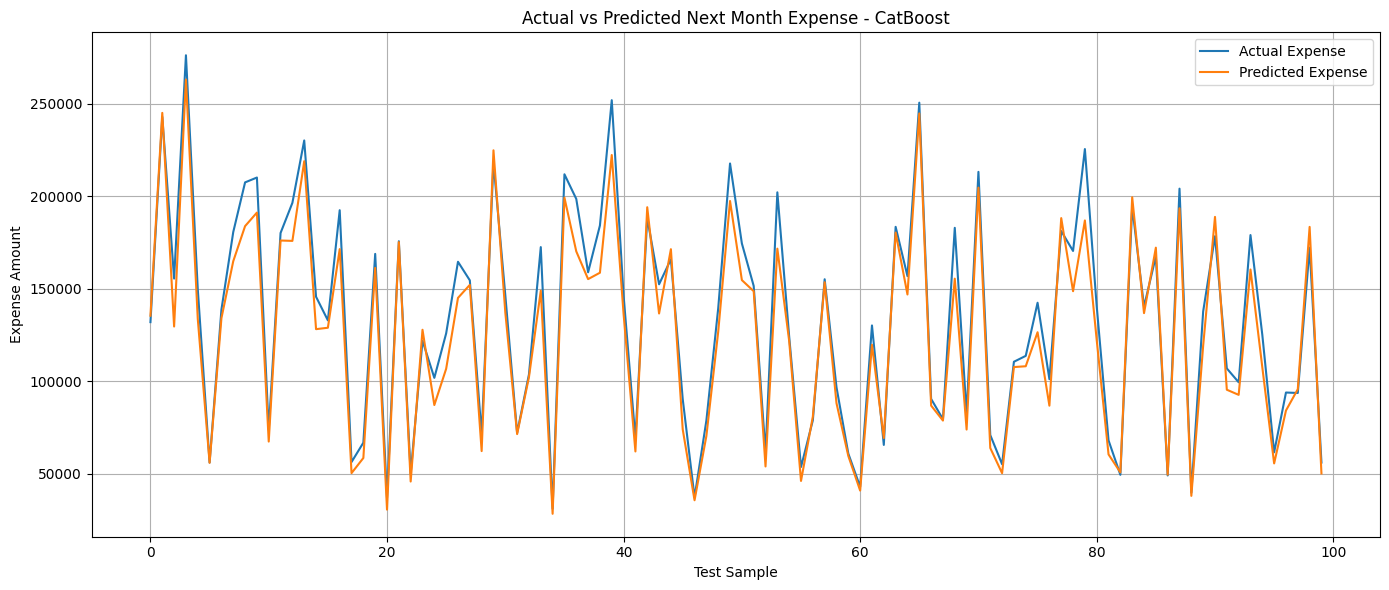

In [24]:
sample_count = 100

plt.figure(figsize=(14, 6))

plt.plot(
    prediction_results["ActualExpense"][:sample_count],
    label="Actual Expense"
)

plt.plot(
    prediction_results["PredictedExpense"][:sample_count],
    label="Predicted Expense"
)

plt.title("Actual vs Predicted Next Month Expense - CatBoost")
plt.xlabel("Test Sample")
plt.ylabel("Expense Amount")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

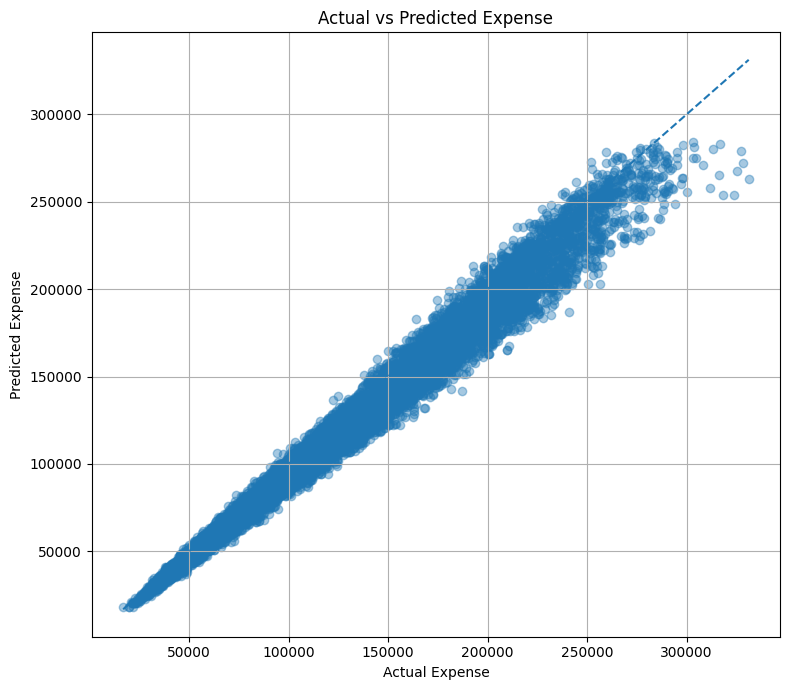

In [25]:
plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

minimum_value = min(y_test.min(), y_pred.min())
maximum_value = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Expense")
plt.xlabel("Actual Expense")
plt.ylabel("Predicted Expense")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": catboost_model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,Total_Expense,48.345078
1,Average_Daily_Expense,44.100739
2,Month,2.770506
3,Transport,1.932991
4,Monthly_Income,0.755255
5,Entertainment,0.199975
6,Food,0.198988
7,Savings,0.191199
8,Health,0.186057
9,Savings_Rate,0.181928


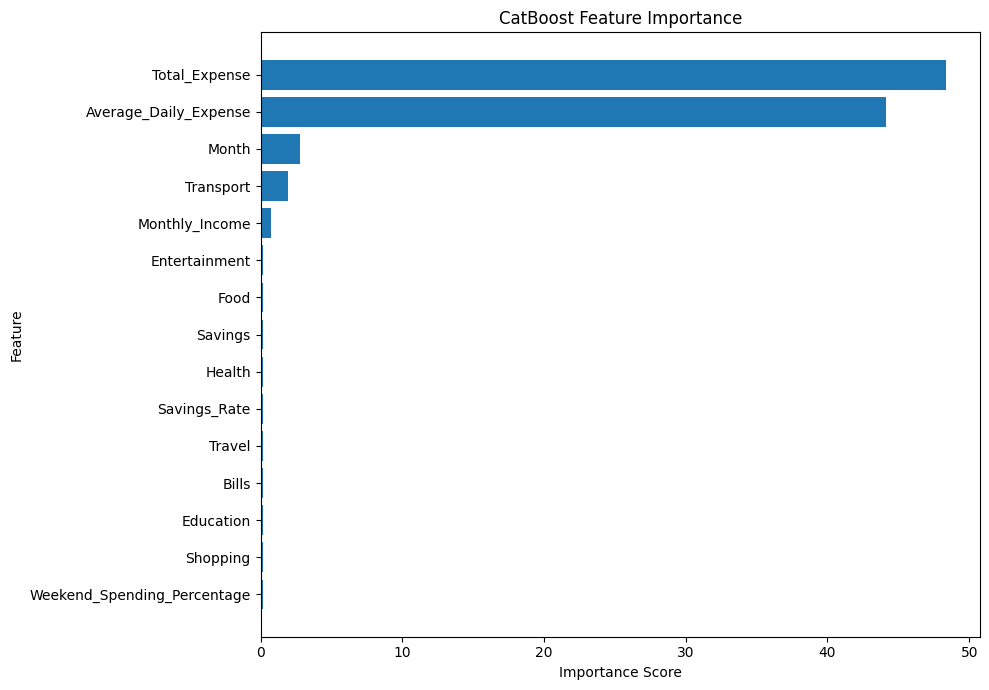

In [27]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("CatBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [28]:
catboost_model.save_model(
    "catboost_expense_prediction_model.cbm"
)

print("Model saved successfully.")

Model saved successfully.


In [29]:
result_table.to_csv(
    "catboost_evaluation_results.csv",
    index=False
)

prediction_results.to_csv(
    "catboost_predictions.csv",
    index=False
)

feature_importance.to_csv(
    "catboost_feature_importance.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.
